# Блок 1. Когортный retention-анализ

**Вопрос:** насколько H&M удерживает клиентов после первой покупки?
Есть ли разница между когортами?

**Данные:** витрина hm.cohorts_mart (ClickHouse)
**Метрика:** retention rate = доля клиентов когорты, купивших в месяц M+N

In [ ]:
import clickhouse_connect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

client = clickhouse_connect.get_client(
    host='localhost', port=8123,
    username='analyst', password='analyst', database='hm'
)

cohorts = client.query_df("""
    SELECT
        cohort_month,
        month_offset,
        cohort_size,
        retained_customers,
        retention_rate
    FROM hm.cohorts_mart
    ORDER BY cohort_month, month_offset
""")

print(f"Строк в витрине: {len(cohorts)}")
print(f"Когорт: {cohorts['cohort_month'].nunique()}")
print(f"Макс. offset: {cohorts['month_offset'].max()}")
cohorts.head(10)

Строк в витрине: 300
Когорт: 24
Макс. offset: 23


,cohort_month,month_offset,cohort_size,retained_customers,retention_rate
0,2018-10-01,0,274220,274483,100.10
1,2018-10-01,1,274220,112718,41.10
2,2018-10-01,2,274220,105664,38.53
3,2018-10-01,3,274220,100717,36.73
4,2018-10-01,4,274220,94559,34.48
5,2018-10-01,5,274220,99517,36.29
6,2018-10-01,6,274220,103020,37.57
7,2018-10-01,7,274220,104234,38.01
8,2018-10-01,8,274220,111896,40.81
9,2018-10-01,9,274220,108195,39.46


In [ ]:
retention_matrix = cohorts.pivot(
    index='cohort_month',
    columns='month_offset',
    values='retention_rate'
)

retention_matrix.index = pd.to_datetime(retention_matrix.index).strftime('%Y-%m')

print(retention_matrix.shape)
retention_matrix.iloc[:5, :6]  # превью первых 5 когорт и 6 офсетов

(24, 24)


month_offset,0,1,2,3,4,5
cohort_month,,,,,,
2018-10,100.10,41.10,38.53,36.73,34.48,36.29
2018-11,100.04,29.12,26.59,24.81,26.34,27.48
2018-12,99.72,22.65,20.09,21.16,22.40,23.01
2019-01,100.16,18.98,19.00,19.93,20.42,22.51
2019-02,99.82,17.98,17.80,17.96,19.80,19.19


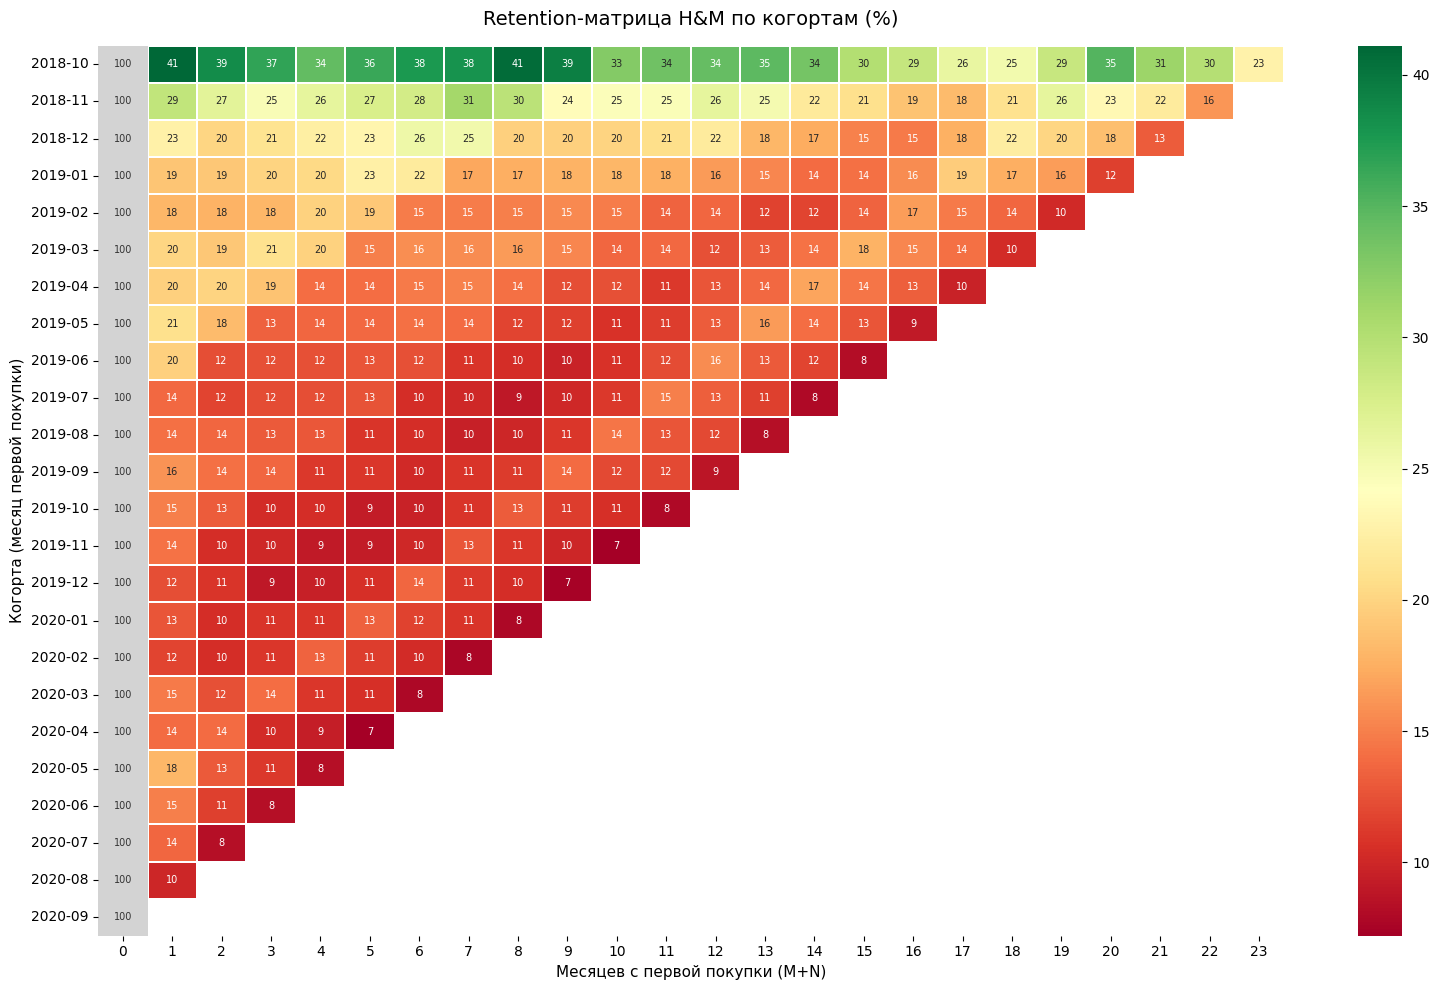

In [4]:
fig, ax = plt.subplots(figsize=(16, 10))

# Матрица без M+0 — для окраски
retention_no_m0 = retention_matrix.copy()
retention_no_m0[0] = np.nan  # убираем M+0 из цветовой шкалы

# Реальный диапазон значений (без M+0)
vmin = retention_no_m0.min().min()
vmax = retention_no_m0.max().max()

mask = retention_no_m0.isnull()

sns.heatmap(
    retention_no_m0,
    mask=mask,
    annot=retention_matrix,  # подписи берём из оригинала (с M+0=100)
    fmt='.0f',
    cmap='RdYlGn',           # красный=низкий, жёлтый=средний, зелёный=высокий
    vmin=vmin, vmax=vmax,
    linewidths=0.3,
    linecolor='white',
    annot_kws={'size': 7},
    ax=ax
)

# M+0 закрашиваем нейтральным серым вручную
for i in range(len(retention_matrix)):
    ax.add_patch(plt.Rectangle(
        (0, i), 1, 1,
        fill=True, color='#d3d3d3', lw=0
    ))
    ax.text(0.5, i + 0.5, '100',
            ha='center', va='center',
            fontsize=7, color='#333333')

ax.set_title('Retention-матрица H&M по когортам (%)', fontsize=14, pad=15)
ax.set_xlabel('Месяцев с первой покупки (M+N)', fontsize=11)
ax.set_ylabel('Когорта (месяц первой покупки)', fontsize=11)
plt.tight_layout()
plt.show()

**Выводы по Блоку 1 (когортный retention):**

Методологические:
- M+0 = 100% по определению. Значение 100.1% у когорты 2018-10 —
  технический артефакт отсечки сентября (несколько сотен клиентов
  с транзакциями и в сен, и в окт). Влияние <0.1%, некритично.
- Ранние когорты (окт 2018 – сер 2019) показывают завышенный retention
  (M+1 до 41%) из-за left truncation: в них попали лояльные «старые»
  клиенты H&M с историей до начала данных.

Содержательные:
- «Чистые» когорты (с ~авг 2019) выходят на плато: реальный M+1 retention
  нового клиента ≈ 13-15%, а не 40%.
- Retention не вымирает до нуля — стабилизируется на 10-13% и держится
  более года. У H&M есть лояльное ядро (~10%), возвращающееся сезонно
  (всплески на M+10..M+12 — летние покупки).
- Выраженного COVID-провала в retention поздних когорт не видно —
  база устойчива (согласуется с выводом 3.1: упала интенсивность,
  не клиентская база).

Решение для бизнеса:
- Критическая точка оттока — переход M+0 → M+1: теряется ~85% новых
  клиентов. Retention-усилия (welcome-цепочка, второй заказ)
  нужно концентрировать в первые 30 дней после первой покупки.
- Лояльное ядро стоит поддерживать сезонными триггерами
  (предложения перед летним пиком).

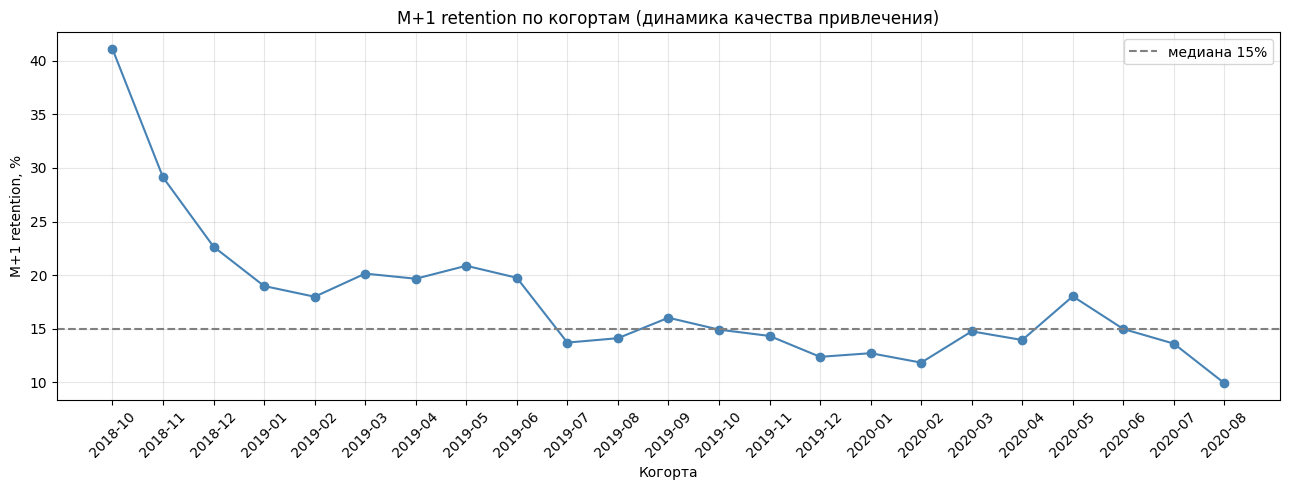

In [5]:
# Сравниваем M+1 retention по всем когортам — есть ли реальный тренд
m1 = cohorts[cohorts['month_offset'] == 1][['cohort_month', 'retention_rate']].copy()
m1['cohort_month'] = pd.to_datetime(m1['cohort_month']).dt.strftime('%Y-%m')

plt.figure(figsize=(13, 5))
plt.plot(m1['cohort_month'], m1['retention_rate'], marker='o', color='steelblue')
plt.axhline(m1['retention_rate'].median(), color='gray', linestyle='--',
            label=f"медиана {m1['retention_rate'].median():.0f}%")
plt.title('M+1 retention по когортам (динамика качества привлечения)')
plt.xlabel('Когорта')
plt.ylabel('M+1 retention, %')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Г4 (пересмотрено): COVID — это период-эффект, а не когортный эффект.**

Исходная гипотеза «у когорт весны 2020 упал retention» не подтвердилась.
M+1 retention когорт 2020-03..05 (14-18%) не отличается от докризисных.
Качество привлечения клиентов в COVID не ухудшилось.

Реальный эффект COVID — календарный: в апреле 2020 просели ВСЕ активные
когорты одновременно (виден по диагонали retention-матрицы), т.к. закрылись
офлайн-магазины. Это шок спроса в моменте, а не свойство привлечённых клиентов.

Дополнительно: истинный M+1 retention новых клиентов H&M ≈ 15% (плато
с середины 2019, после очистки от left-truncation). Ранние значения (до 41%)
завышены старыми клиентами.